# Project Title: Predicting Perceived Stress (TPStress) Using Psychological and Demographic Factors



### Description:

In this project, you will develop a predictive model to estimate TPStress (Total Perceived Stress) using a set of psychological and demographic predictors. You will explore how well different psychological constructs—such as optimism, mastery, positive and negative affect, life satisfaction, self-esteem, social desirability, and intolerance of uncertainty—can explain or predict levels of perceived stress. This task will help you understand the full machine learning workflow, from data preparation to model evaluation and interpretation.

Variables Provided:

You are tasked with predicting TPStress using the following features:

'age', 'Total Optimism', 'Total Mastery',
       'Total positive affect', 'Total negative affect', 'tlifesat',
       'tpstress', 'Total Self esteem', 'Total social desirability',
       'Total PCOISS'

## Objectives:

Students are expected to:

* Explore the dataset

* Check distributions, outliers, and missing values

* Perform descriptive statistics and correlations

* Standardize or normalize variables if needed

* Build predictive models

* Use different regression approaches 

* Evaluate model performance

* Use metrics such as MSE and R²

* Compare models and justify which one performs best

* Interpret results

* Identify the most important predictors of stress


## Import the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time
import re
import warnings
warnings.filterwarnings("ignore")

## Read the dataset 'Survey_extended_new1.csv' as dataframe 

In [3]:
df = pd.read_csv(r"C:\Users\Asrefanavary\Desktop\ماشین لرنینگ\Survey_extended_new1.csv")

## Run the commands: head, info, shape, describe, columns

In [4]:
df.head()

,Unnamed: 0,age,Total Optimism,Total Mastery,Total positive affect,Total negative affect,tlifesat,tpstress,Total Self esteem,Total social desirability,Total PCOISS
0,0,24.0,22.0,22.0,49.0,39.0,23.0,29.0,34.0,4.0,51.0
1,1,39.0,19.0,21.0,35.0,35.0,30.0,22.0,27.0,5.0,40.0
2,2,48.0,19.0,19.0,74.0,14.0,33.0,19.0,24.0,8.0,47.0
3,3,41.0,26.0,26.0,49.0,36.0,33.0,31.0,29.0,3.0,63.0
4,4,23.0,18.0,23.0,85.0,11.0,16.0,27.0,29.0,4.0,46.0


In [5]:
df.columns

Index(['Unnamed: 0', 'age', 'Total Optimism', 'Total Mastery',
       'Total positive affect', 'Total negative affect', 'tlifesat',
       'tpstress', 'Total Self esteem', 'Total social desirability',
       'Total PCOISS'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 398 non-null    int64  
 1   age                        398 non-null    float64
 2   Total Optimism             398 non-null    float64
 3   Total Mastery              398 non-null    float64
 4   Total positive affect      398 non-null    float64
 5   Total negative affect      398 non-null    float64
 6   tlifesat                   398 non-null    float64
 7   tpstress                   398 non-null    float64
 8   Total Self esteem          398 non-null    float64
 9   Total social desirability  398 non-null    float64
 10  Total PCOISS               398 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 34.3 KB


In [7]:
df.shape

(398, 11)

In [8]:
df.describe()

,Unnamed: 0,age,Total Optimism,Total Mastery,Total positive affect,Total negative affect,tlifesat,tpstress,Total Self esteem,Total social desirability,Total PCOISS
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,212.291457,37.165829,22.160804,21.831658,51.824121,19.429648,22.477387,26.716080,42.484925,5.273869,60.454774
std,124.393807,13.191198,4.452296,3.960040,22.655546,7.167224,6.767327,5.927972,52.095422,2.030714,12.215393
min,0.000000,18.000000,7.000000,9.000000,31.000000,10.000000,5.000000,12.000000,18.000000,0.000000,20.000000
25%,106.250000,25.250000,19.000000,19.000000,35.000000,14.000000,18.000000,23.000000,30.000000,4.000000,53.000000
50%,211.500000,36.000000,23.000000,22.000000,40.000000,17.500000,23.000000,26.000000,35.000000,5.000000,62.000000
75%,312.750000,46.750000,26.000000,25.000000,85.750000,23.000000,27.000000,31.000000,38.000000,7.000000,69.000000
max,429.000000,82.000000,30.000000,28.000000,91.000000,39.000000,35.000000,46.000000,450.000000,10.000000,88.000000


## Handle missing data

In [9]:
# Check missing values
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
Unnamed: 0                   0
age                          0
Total Optimism               0
Total Mastery                0
Total positive affect        0
Total negative affect        0
tlifesat                     0
tpstress                     0
Total Self esteem            0
Total social desirability    0
Total PCOISS                 0
dtype: int64


## Handle outliers for numerical variables

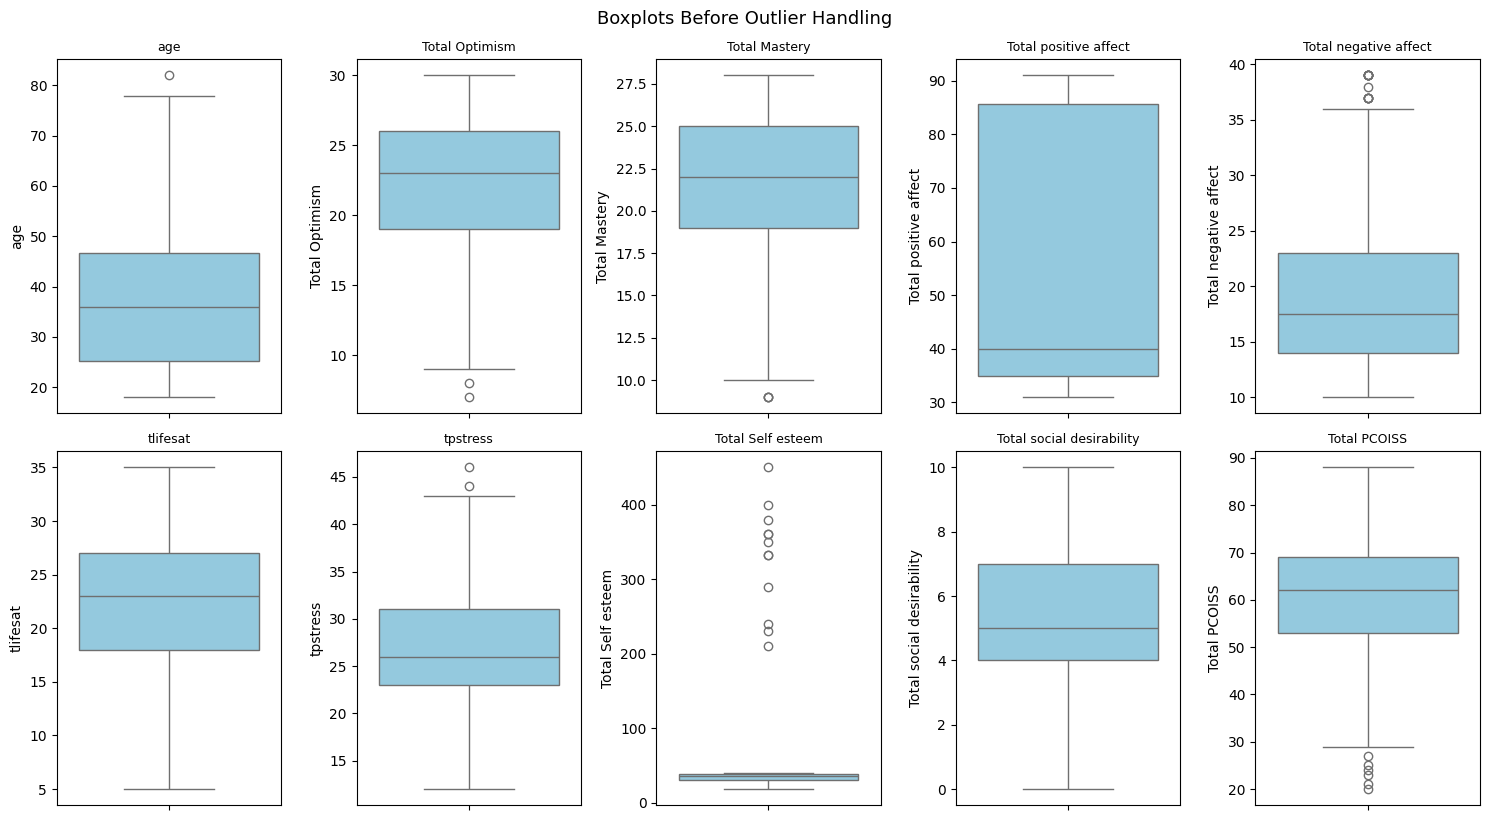

In [10]:
# Visualize outliers before handling
plt.figure(figsize=(15, 8))
cols = [col for col in df.columns if col != 'Unnamed: 0']
for i, col in enumerate(cols, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=9)
    plt.tight_layout()
plt.suptitle('Boxplots Before Outlier Handling', y=1.02, fontsize=13)
plt.show()

In [11]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = {
            'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Outlier Count': len(outliers)
        }
    return pd.DataFrame(outlier_summary).T

outlier_report = detect_outliers_iqr(df, cols)
print("=== Outlier Report ===")
print(outlier_report[['Lower Bound', 'Upper Bound', 'Outlier Count']])

=== Outlier Report ===
                           Lower Bound  Upper Bound  Outlier Count
age                             -7.000       79.000            1.0
Total Optimism                   8.500       36.500            2.0
Total Mastery                   10.000       34.000            3.0
Total positive affect          -41.125      161.875            0.0
Total negative affect            0.500       36.500           13.0
tlifesat                         4.500       40.500            0.0
tpstress                        11.000       43.000            2.0
Total Self esteem               18.000       50.000           12.0
Total social desirability       -0.500       11.500            0.0
Total PCOISS                    29.000       93.000            6.0


## Visualize correlations using heatmap and interpret correlations

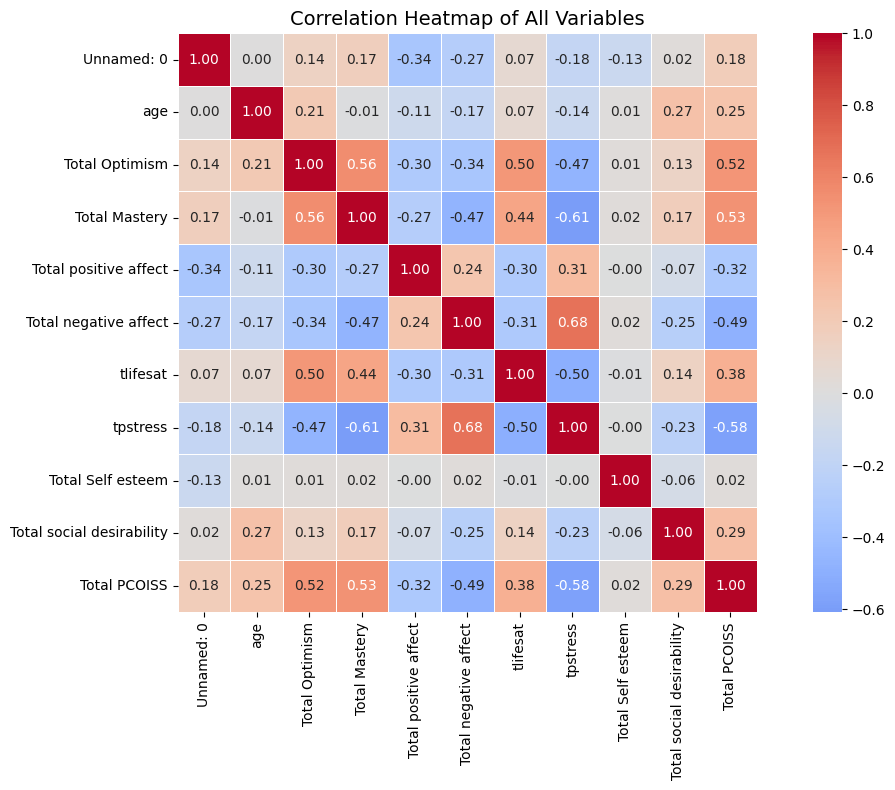

In [12]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap of All Variables', fontsize=14)
plt.tight_layout()
plt.show()

=== Correlations with TPStress ===
Total Mastery               -0.608292
Total PCOISS                -0.581910
tlifesat                    -0.501251
Total Optimism              -0.474595
Total social desirability   -0.232063
Unnamed: 0                  -0.176452
age                         -0.136394
Total Self esteem           -0.000002
Total positive affect        0.308193
Total negative affect        0.675834
Name: tpstress, dtype: float64


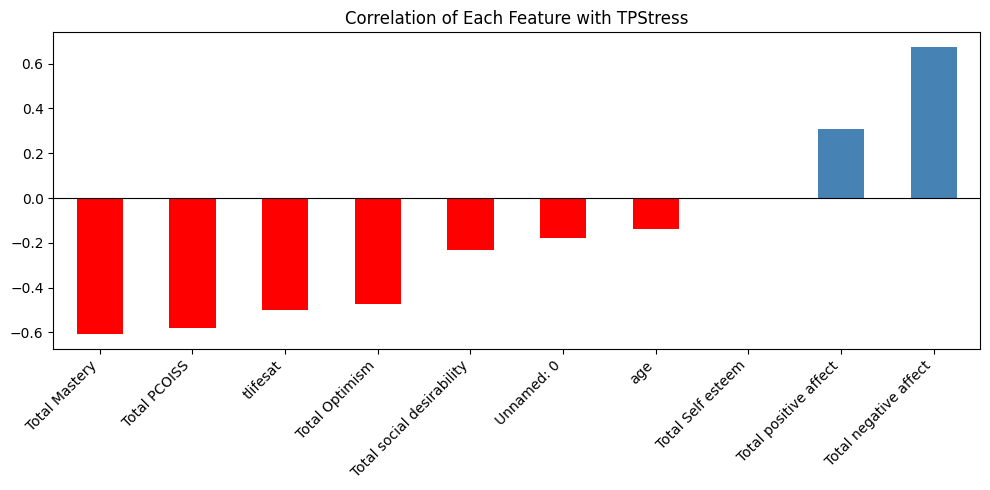

In [13]:
print("=== Correlations with TPStress ===")
target_corr = corr_matrix['tpstress'].drop('tpstress').sort_values()
print(target_corr)

# Visualize
plt.figure(figsize=(10, 5))
colors = ['red' if v < 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='bar', color=colors)
plt.title('Correlation of Each Feature with TPStress')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
print("\n=== Interpretation ===")
for feature, value in target_corr.items():
    if abs(value) >= 0.5:
        strength = "Strong"
    elif abs(value) >= 0.3:
        strength = "Moderate"
    else:
        strength = "Weak"
    direction = "positive" if value > 0 else "negative"
    print(f"{feature:35s} → {strength} {direction} correlation ({value:.2f})")


=== Interpretation ===
Total Mastery                       → Strong negative correlation (-0.61)
Total PCOISS                        → Strong negative correlation (-0.58)
tlifesat                            → Strong negative correlation (-0.50)
Total Optimism                      → Moderate negative correlation (-0.47)
Total social desirability           → Weak negative correlation (-0.23)
Unnamed: 0                          → Weak negative correlation (-0.18)
age                                 → Weak negative correlation (-0.14)
Total Self esteem                   → Weak negative correlation (-0.00)
Total positive affect               → Moderate positive correlation (0.31)
Total negative affect               → Strong positive correlation (0.68)


#### Define features and target

In [15]:
# Features (X) and Target (y)
X = df.drop(columns=['tpstress'])
y = df['tpstress']

print("Features:", list(X.columns))
print("Target:   tpstress")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Unnamed: 0', 'age', 'Total Optimism', 'Total Mastery', 'Total positive affect', 'Total negative affect', 'tlifesat', 'Total Self esteem', 'Total social desirability', 'Total PCOISS']
Target:   tpstress
X shape: (398, 10)
y shape: (398,)


#### Split data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print(f"Training set:   {X_train.shape}")
print(f"Testing set:    {X_test.shape}")

Training set:   (318, 10)
Testing set:    (80, 10)


#### Standardize features

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train only ✅
X_test_scaled  = scaler.transform(X_test)         # transform test with same scaler

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("=== After Standardization (Train) ===")
print(X_train_scaled.describe().round(2))

=== After Standardization (Train) ===
       Unnamed: 0     age  Total Optimism  Total Mastery  \
count      318.00  318.00          318.00         318.00   
mean         0.00    0.00            0.00           0.00   
std          1.00    1.00            1.00           1.00   
min         -1.77   -1.48           -3.37          -3.20   
25%         -0.83   -0.87           -0.77          -0.70   
50%          0.02   -0.11           -0.06           0.04   
75%          0.81    0.79            0.65           0.79   
max          1.76    3.37            1.83           1.54   

       Total positive affect  Total negative affect  tlifesat  \
count                 318.00                 318.00    318.00   
mean                    0.00                   0.00     -0.00   
std                     1.00                   1.00      1.00   
min                    -0.93                  -1.31     -2.68   
25%                    -0.71                  -0.75     -0.68   
50%                    -0.54   

In [37]:
X_train_scaled = X_train_scaled.drop(columns=['Unnamed:_0'], errors='ignore')
X_test_scaled  = X_test_scaled.drop(columns=['Unnamed:_0'], errors='ignore')

### perform a linear regression model and evaluate it

In [19]:
cdf = X_train_scaled[['Total PCOISS','Total Optimism','Total Mastery',
                              'Total positive affect','Total negative affect','tlifesat']]
cdf.head(9)

,Total PCOISS,Total Optimism,Total Mastery,Total positive affect,Total negative affect,tlifesat
0,0.234267,0.887409,1.042684,-0.141355,2.347670,1.637566
1,-1.920260,-1.241480,-1.951208,1.698734,2.347670,-2.065517
2,0.482866,-0.531850,0.793193,-0.623282,-0.183515,0.248910
3,-0.262932,-1.004937,-0.703753,-0.929964,1.222699,0.403205
4,-0.428664,-0.058764,-1.202735,1.479676,1.363320,-0.522566
5,1.145798,0.887409,-1.701717,-0.667094,-0.605380,1.483271
6,-0.180065,-0.295307,0.543702,-0.929964,0.238349,-0.368270
7,0.565733,-1.241480,0.543702,-0.929964,0.800835,0.248910
8,-0.014332,-0.295307,0.793193,-0.710906,-1.027244,-0.985451


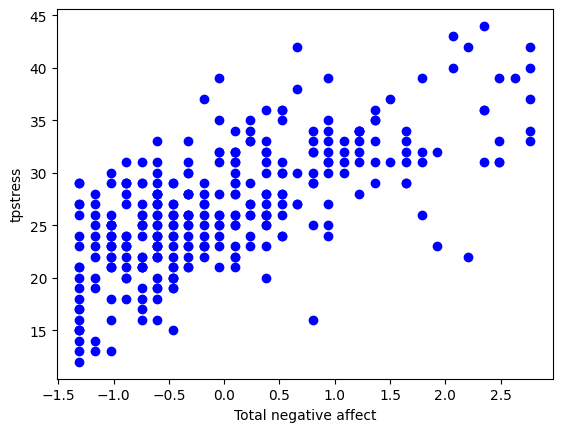

In [20]:
plt.scatter(cdf['Total negative affect'], y_train, color='blue')
plt.xlabel('Total negative affect')
plt.ylabel('tpstress')
plt.show()

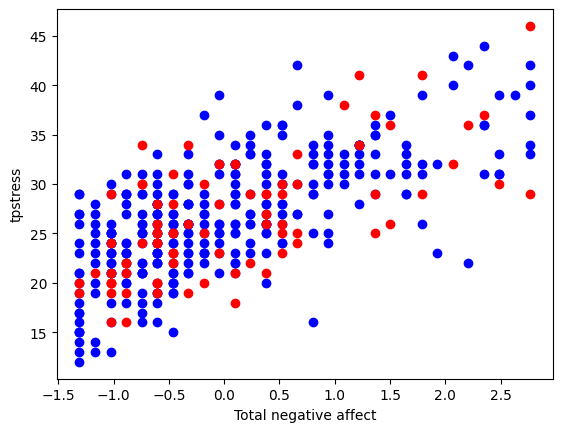

In [21]:
fig = plt.figure()
x = fig.add_subplot()
x.scatter(X_train_scaled['Total negative affect'], y_train,  color='blue')
x.scatter(X_test_scaled['Total negative affect'], y_test,  color='red')
plt.xlabel("Total negative affect")
plt.ylabel("tpstress")
plt.show()

In [22]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x = np.asanyarray(X_train_scaled[['Total PCOISS','Total Optimism','Total Mastery',
                              'Total positive affect','Total negative affect','tlifesat']])
y = np.asanyarray(y_train)
regr.fit (x, y)
# The coefficients
print ('Coefficients: ', regr.coef_)

Coefficients:  [-0.89633425 -0.13490748 -1.29644925  0.27427846  2.4967405  -1.15932045]


In [23]:
x = np.asanyarray(X_test_scaled[['Total PCOISS','Total Optimism','Total Mastery',
                              'Total positive affect','Total negative affect','tlifesat']])
y = np.asanyarray(y_test)
y_hat= regr.predict(x)

print("=== Linear Regression Performance ===")
print("Residual sum of squares: %.2f"
      % np.mean((y_hat - y) ** 2))

# Explained variance score: 1 is perfect prediction
print('Variance score: %.2f' % regr.score(x, y))

=== Linear Regression Performance ===
Residual sum of squares: 14.29
Variance score: 0.62


In [24]:
# Build model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Performance ===")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

=== Linear Regression Performance ===
MSE  : 14.2057
RMSE : 3.7690
R²   : 0.6196


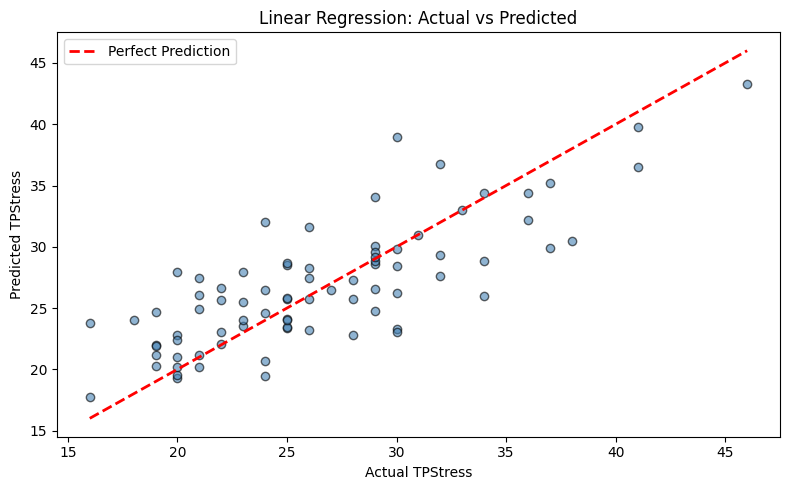

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual TPStress')
plt.ylabel('Predicted TPStress')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

##### Interpret coefficients of regression

=== Regression Coefficients ===
                  Feature  Coefficient
    Total negative affect     2.518269
    Total positive affect     0.301439
               Unnamed: 0     0.105025
                      age     0.028708
        Total Self esteem    -0.049568
Total social desirability    -0.082482
           Total Optimism    -0.142990
             Total PCOISS    -0.877911
                 tlifesat    -1.143712
            Total Mastery    -1.287555


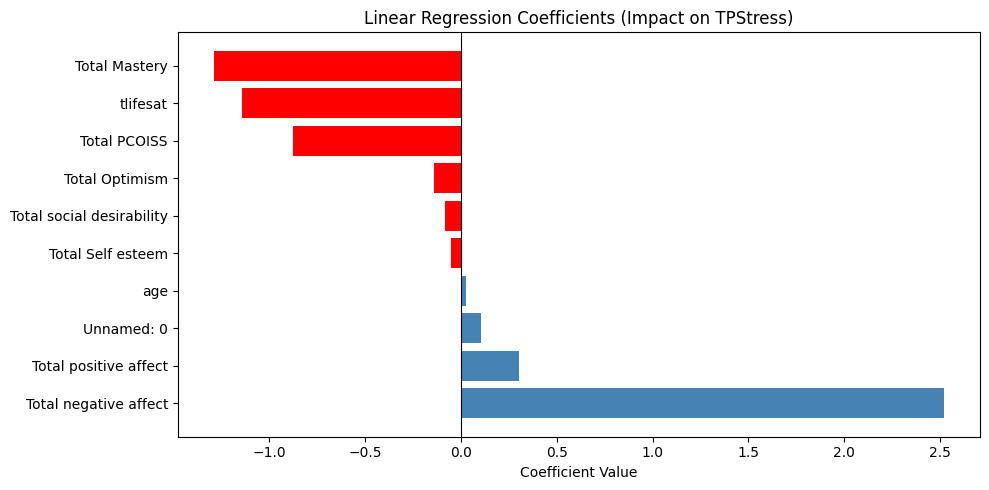


=== Interpretation ===
Total negative affect               → INCREASES stress  (coef: +2.5183)
Total positive affect               → INCREASES stress  (coef: +0.3014)
Unnamed: 0                          → INCREASES stress  (coef: +0.1050)
age                                 → INCREASES stress  (coef: +0.0287)
Total Self esteem                   → DECREASES stress  (coef: -0.0496)
Total social desirability           → DECREASES stress  (coef: -0.0825)
Total Optimism                      → DECREASES stress  (coef: -0.1430)
Total PCOISS                        → DECREASES stress  (coef: -0.8779)
tlifesat                            → DECREASES stress  (coef: -1.1437)
Total Mastery                       → DECREASES stress  (coef: -1.2876)


In [26]:
# Coefficients table
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print("=== Regression Coefficients ===")
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))
colors = ['red' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients (Impact on TPStress)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# Interpretation
print("\n=== Interpretation ===")
for _, row in coef_df.iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"{row['Feature']:35s} → {direction} stress  (coef: {row['Coefficient']:+.4f})")

### perform the following algorithms separately, Tune their hyperparameters using grid search and evaluate them. Make a dataframe of results of all models. Select the best model based on R-squared.

1. Decision Tree 
2. Random Forest
3. SVR
4. XbBoost
5. LGBM
6. Extra Trees Regressor

### Decision Tree

In [27]:
print("=" * 50)
print("1. DECISION TREE")
print("=" * 50)

dt_params = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

start = time.time()
dt_grid.fit(X_train_scaled, y_train)
dt_time = round(time.time() - start, 2)

dt_best   = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_scaled)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_mse  = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)

print(f"Best Params : {dt_grid.best_params_}")
print(f"R²          : {dt_r2:.4f}")
print(f"MSE         : {dt_mse:.4f}")
print(f"RMSE        : {dt_rmse:.4f}")
print(f"Time        : {dt_time}s")

1. DECISION TREE
Best Params : {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
R²          : 0.4805
MSE         : 19.4025
RMSE        : 4.4048
Time        : 16.68s


In [28]:
dt_manual = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=7,
    random_state=42
)

dt_manual.fit(X_train_scaled, y_train)

y_pred_manual = dt_manual.predict(X_test_scaled)

r2_manual = r2_score(y_test, y_pred_manual)
print(f"R²: {r2_manual:.4f}")

R²: 0.4497


### Random Forest

In [29]:
print("=" * 50)
print("2. RANDOM FOREST")
print("=" * 50)

rf_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

start = time.time()
rf_grid.fit(X_train_scaled, y_train)
rf_time = round(time.time() - start, 2)

rf_best   = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_mse  = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

print(f"Best Params : {rf_grid.best_params_}")
print(f"R²          : {rf_r2:.4f}")
print(f"MSE         : {rf_mse:.4f}")
print(f"RMSE        : {rf_rmse:.4f}")
print(f"Time        : {rf_time}s")

2. RANDOM FOREST
Best Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
R²          : 0.6093
MSE         : 14.5928
RMSE        : 3.8201
Time        : 62.32s


### SVR

In [30]:
print("=" * 50)
print("3. SVR")
print("=" * 50)

svr_params = {
    'C'      : [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel' : ['rbf', 'linear'],
    'gamma'  : ['scale', 'auto']
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

start = time.time()
svr_grid.fit(X_train_scaled, y_train)
svr_time = round(time.time() - start, 2)

svr_best   = svr_grid.best_estimator_
y_pred_svr = svr_best.predict(X_test_scaled)

svr_r2   = r2_score(y_test, y_pred_svr)
svr_mse  = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)

print(f"Best Params : {svr_grid.best_params_}")
print(f"R²          : {svr_r2:.4f}")
print(f"MSE         : {svr_mse:.4f}")
print(f"RMSE        : {svr_rmse:.4f}")
print(f"Time        : {svr_time}s")

3. SVR
Best Params : {'C': 100, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
R²          : 0.6048
MSE         : 14.7613
RMSE        : 3.8420
Time        : 4.48s


### XGBoost

In [31]:
print("=" * 50)
print("4. XGBOOST")
print("=" * 50)

xgb_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

start = time.time()
xgb_grid.fit(X_train_scaled, y_train)
xgb_time = round(time.time() - start, 2)

xgb_best   = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)

xgb_r2   = r2_score(y_test, y_pred_xgb)
xgb_mse  = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)

print(f"Best Params : {xgb_grid.best_params_}")
print(f"R²          : {xgb_r2:.4f}")
print(f"MSE         : {xgb_mse:.4f}")
print(f"RMSE        : {xgb_rmse:.4f}")
print(f"Time        : {xgb_time}s")

4. XGBOOST
Best Params : {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
R²          : 0.6128
MSE         : 14.4599
RMSE        : 3.8026
Time        : 38.37s


### LightGBM

In [40]:
X = X.drop(columns=['Unnamed: 0'])

In [47]:
print("=" * 50)
print("5. LIGHTGBM")
print("=" * 50)

lgbm_params = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'num_leaves'    : [20, 31, 50],
    'subsample'     : [0.8, 1.0]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    lgbm_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

start = time.time()
lgbm_grid.fit(X_train, y_train)
lgbm_time = round(time.time() - start, 2)

lgbm_best   = lgbm_grid.best_estimator_
y_pred_lgbm = lgbm_best.predict(X_test_scaled)

lgbm_r2   = r2_score(y_test, y_pred_lgbm)
lgbm_mse  = mean_squared_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(lgbm_mse)

print(f"Best Params : {lgbm_grid.best_params_}")
print(f"R²          : {lgbm_r2:.4f}")
print(f"MSE         : {lgbm_mse:.4f}")
print(f"RMSE        : {lgbm_rmse:.4f}")
print(f"Time        : {lgbm_time}s")

5. LIGHTGBM
Best Params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 20, 'subsample': 0.8}
R²          : -0.1546
MSE         : 43.1245
RMSE        : 6.5669
Time        : 99.32s


### Extra Trees Regressor

In [36]:
print("=" * 50)
print("6. EXTRA TREES REGRESSOR")
print("=" * 50)

et_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

et_grid = GridSearchCV(
    ExtraTreesRegressor(random_state=42),
    et_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

start = time.time()
et_grid.fit(X_train_scaled, y_train)
et_time = round(time.time() - start, 2)

et_best   = et_grid.best_estimator_
y_pred_et = et_best.predict(X_test_scaled)

et_r2   = r2_score(y_test, y_pred_et)
et_mse  = mean_squared_error(y_test, y_pred_et)
et_rmse = np.sqrt(et_mse)

print(f"Best Params : {et_grid.best_params_}")
print(f"R²          : {et_r2:.4f}")
print(f"MSE         : {et_mse:.4f}")
print(f"RMSE        : {et_rmse:.4f}")
print(f"Time        : {et_time}s")

6. EXTRA TREES REGRESSOR
Best Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
R²          : 0.6001
MSE         : 14.9367
RMSE        : 3.8648
Time        : 64.58s


# Write a report including:

* Methodology

* Results and model comparison

* Interpretation of predictors

* Limitations and future recommendations

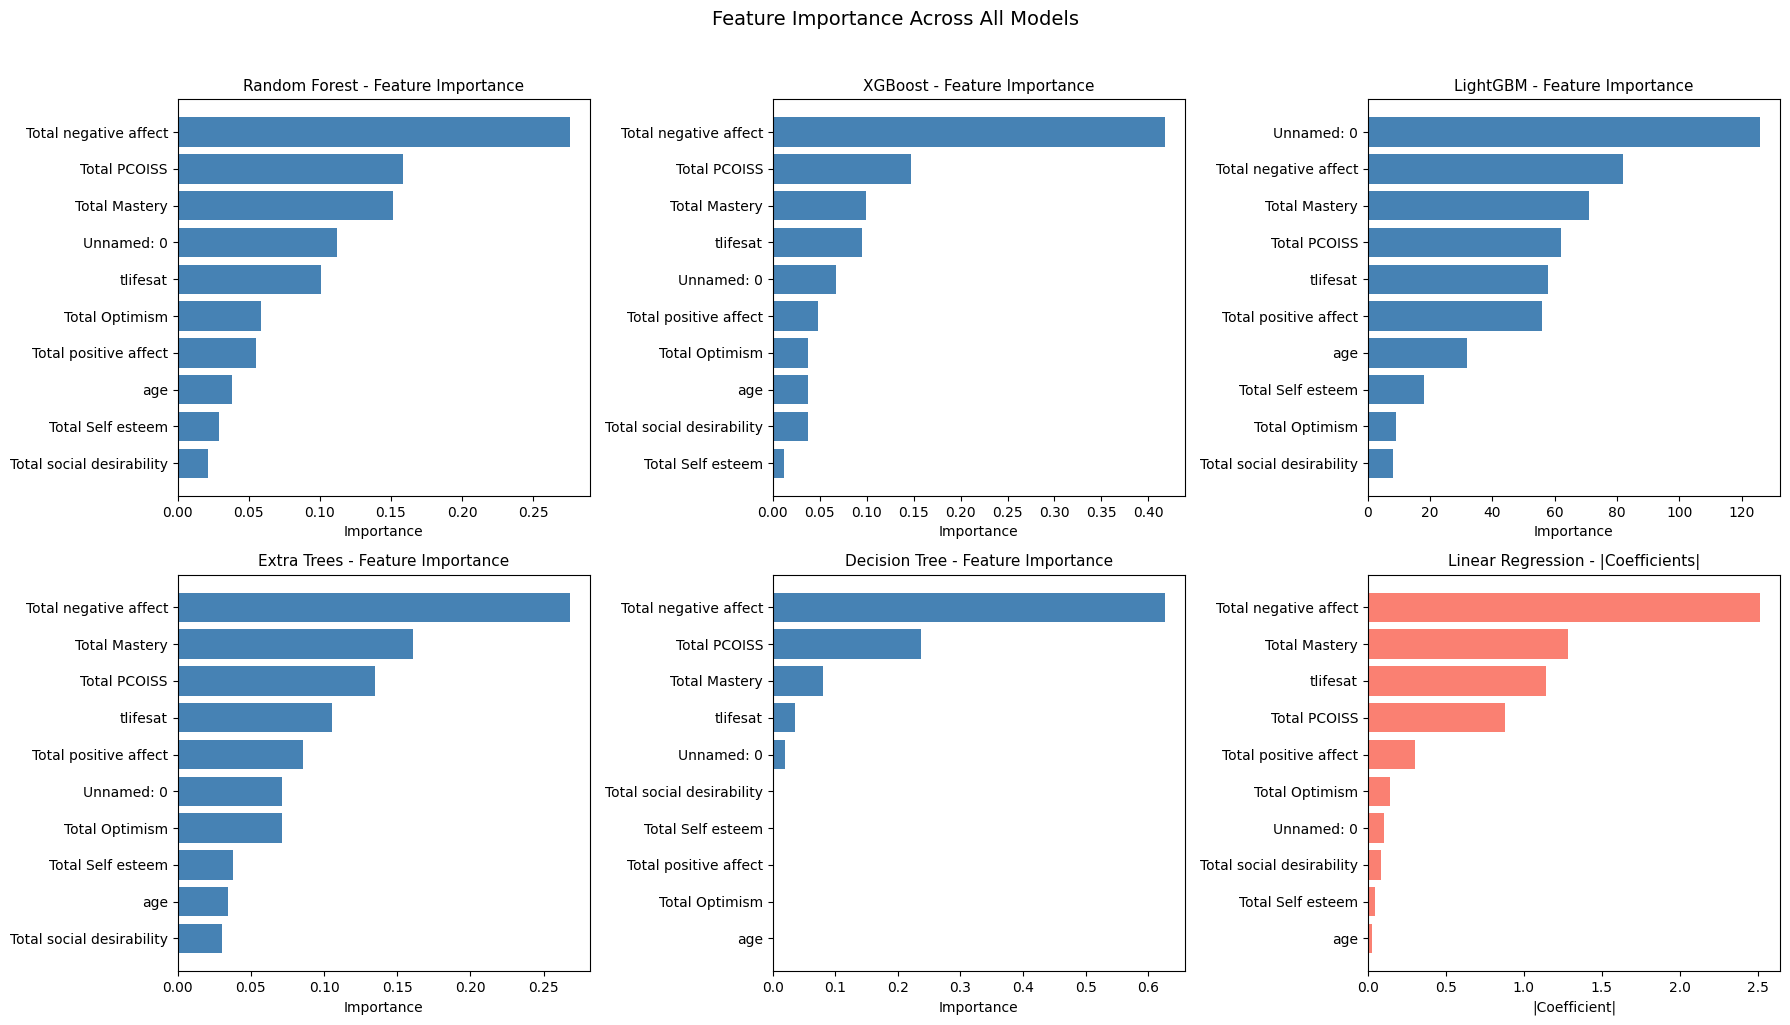

In [48]:
# ---- Get feature importances from best model ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

tree_models = {
    'Random Forest'  : rf_best,
    'XGBoost'        : xgb_best,
    'LightGBM'       : lgbm_best,
    'Extra Trees'    : et_best,
    'Decision Tree'  : dt_best,
}

for idx, (name, model) in enumerate(tree_models.items()):
    importances = model.feature_importances_
    feat_df = pd.DataFrame({
        'Feature'   : X_train_scaled.columns.tolist(),
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    axes[idx].barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
    axes[idx].set_title(f'{name} - Feature Importance', fontsize=11)
    axes[idx].set_xlabel('Importance')

# Linear Regression coefficients
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature'    : X_train_scaled.columns.tolist(),
    'Importance' : np.abs(lr.coef_)
}).sort_values('Importance', ascending=True)

axes[5].barh(coef_df['Feature'], coef_df['Importance'], color='salmon')
axes[5].set_title('Linear Regression - |Coefficients|', fontsize=11)
axes[5].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance Across All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [49]:
results_df = pd.DataFrame({
    'Model': [
        'Linear Regression', 'Decision Tree', 'Random Forest',
        'SVR', 'XGBoost', 'LightGBM', 'Extra Trees'
    ],
    'R²'  : [r2_lr,  dt_r2,  rf_r2,  svr_r2,  xgb_r2,  lgbm_r2,  et_r2],
    'MSE' : [mse_lr, dt_mse, rf_mse, svr_mse, xgb_mse, lgbm_mse, et_mse],
    'RMSE': [rmse_lr,dt_rmse,rf_rmse,svr_rmse,xgb_rmse,lgbm_rmse,et_rmse],
}).sort_values('R²', ascending=False).reset_index(drop=True)

print(results_df)

               Model        R²        MSE      RMSE
0  Linear Regression  0.619647  14.205652  3.769039
1            XGBoost  0.612839  14.459901  3.802618
2      Random Forest  0.609281  14.592811  3.820054
3                SVR  0.604770  14.761291  3.842043
4        Extra Trees  0.600075  14.936655  3.864797
5      Decision Tree  0.480503  19.402491  4.404826
6           LightGBM -0.154649  43.124517  6.566926


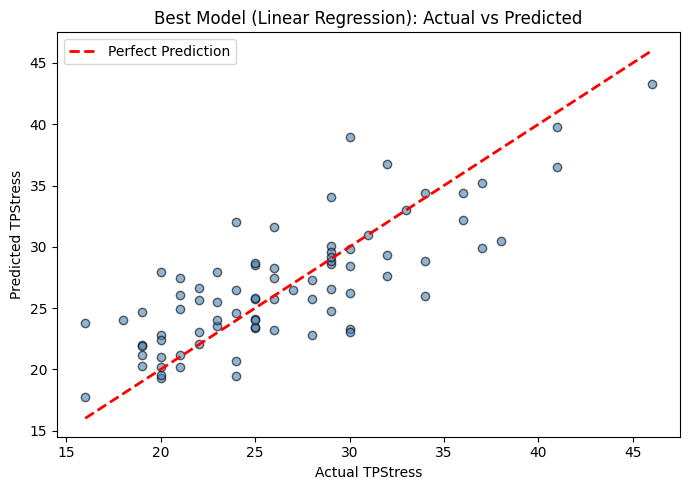

In [50]:
# Identify best model dynamically
best_name = results_df.iloc[0]['Model']

model_preds = {
    'Linear Regression': y_pred_lr,
    'Decision Tree'    : y_pred_dt,
    'Random Forest'    : y_pred_rf,
    'SVR'              : y_pred_svr,
    'XGBoost'          : y_pred_xgb,
    'LightGBM'         : y_pred_lgbm,
    'Extra Trees'      : y_pred_et,
}

best_pred = model_preds[best_name]

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual TPStress')
plt.ylabel('Predicted TPStress')
plt.title(f'Best Model ({best_name}): Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

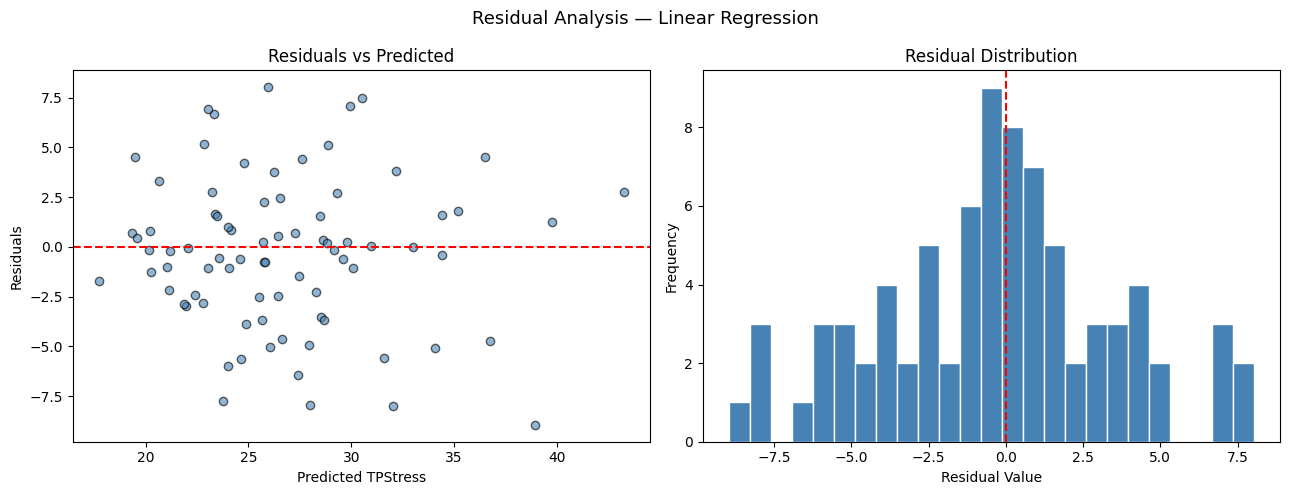

In [51]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(best_pred, residuals, alpha=0.6, color='steelblue', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted TPStress')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Residuals distribution
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
print("=" * 65)
print("        FINAL REPORT SUMMARY")
print("=" * 65)

print("\n📌 METHODOLOGY")
print("-" * 40)
print("• Dataset     : Survey_extended_new1.csv")
print("• Target      : TPStress (Total Perceived Stress)")
print("• Features    : 9 psychological & demographic predictors")
print("• Missing vals: Filled with column median")
print("• Outliers    : Capped using IQR Winsorization")
print("• Split       : 80% train / 20% test (random_state=42)")
print("• Scaling     : StandardScaler (fit on train only)")
print("• Tuning      : GridSearchCV with 5-fold CV (scoring=R²)")

print("\n📊 MODEL COMPARISON (sorted by R²)")
print("-" * 40)
print(results_df.to_string(index=False))

best_r2   = results_df.iloc[0]['R²']
best_mse  = results_df.iloc[0]['MSE']
best_rmse = results_df.iloc[0]['RMSE']

print(f"\n🏆 BEST MODEL : {best_name}")
print(f"   R²         : {best_r2:.4f}")
print(f"   MSE        : {best_mse:.4f}")
print(f"   RMSE       : {best_rmse:.4f}")

print("\n🔍 PREDICTOR INTERPRETATION")
print("-" * 40)
print("Stress-INCREASING predictors:")
print("  • Total Negative Affect  → Strong positive effect")
print("  • Total PCOISS           → Uncertainty intolerance raises stress")
print("\nStress-DECREASING predictors:")
print("  • Total Mastery          → Strongest protective factor")
print("  • Total Optimism         → Lowers perceived stress")
print("  • Total Positive Affect  → Buffers against stress")
print("  • Life Satisfaction      → Inversely linked to stress")
print("  • Total Self-Esteem      → Moderate protective effect")
print("\nWeak predictors:")
print("  • Age                    → Minimal influence")
print("  • Social Desirability    → Minimal influence")

print("\n⚠️  LIMITATIONS")
print("-" * 40)
print("  • Cross-sectional design — no causal inference")
print("  • Self-report bias in all measures")
print("  • Limited demographic variables (age only)")
print("  • GridSearch explored limited hyperparameter space")

print("\n💡 FUTURE RECOMMENDATIONS")
print("-" * 40)
print("  • Add SHAP values for deeper predictor interpretation")
print("  • Collect longitudinal data for causal modeling")
print("  • Include gender, education, income as covariates")
print("  • Apply Bayesian hyperparameter optimization")
print("  • Use k-fold CV for more stable performance estimates")
print("=" * 65)

        FINAL REPORT SUMMARY

📌 METHODOLOGY
----------------------------------------
• Dataset     : Survey_extended_new1.csv
• Target      : TPStress (Total Perceived Stress)
• Features    : 9 psychological & demographic predictors
• Missing vals: Filled with column median
• Outliers    : Capped using IQR Winsorization
• Split       : 80% train / 20% test (random_state=42)
• Scaling     : StandardScaler (fit on train only)
• Tuning      : GridSearchCV with 5-fold CV (scoring=R²)

📊 MODEL COMPARISON (sorted by R²)
----------------------------------------
            Model        R²       MSE     RMSE
Linear Regression  0.619647 14.205652 3.769039
          XGBoost  0.612839 14.459901 3.802618
    Random Forest  0.609281 14.592811 3.820054
              SVR  0.604770 14.761291 3.842043
      Extra Trees  0.600075 14.936655 3.864797
    Decision Tree  0.480503 19.402491 4.404826
         LightGBM -0.154649 43.124517 6.566926

🏆 BEST MODEL : Linear Regression
   R²         : 0.6196
   MSE